In [6]:
from tensorflow import keras
from keras import layers
from keras.models import Sequential
from keras.layers import Dense, Dropout, BatchNormalization
import numpy as np
from hoda_loader import load_hoda
import matplotlib.pyplot as plt

In [7]:
# Load pre-shuffled data into train and test sets
X_train, y_train, X_test, y_test = load_hoda(training_sample_size=3500, test_sample_size=400, size=28)

In [8]:
# Pre-process input data
'''standard our data values to the range [-1, 1]'''
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
X_train /= (X_train - 127.5) / 127.5
X_test /= (X_test - 127.5) / 127.5

In [9]:
# Reshape to original image shape (n x 784) ==> (n x 28 x 28 x 1)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

In [10]:
# Define model architecture
model = Sequential()
model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(28, 28, 1)))
model.add(BatchNormalization())
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(layers.Dense(10, activation='softmax'))

# Compile the model
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['sparse_categorical_accuracy'])

# Fit model on training data
history = model.fit(X_train, y_train, epochs=200, batch_size=256, validation_split=0.2)

C:\Users\aydin\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 403ms/step - loss: 2.8925 - sparse_categorical_accuracy: 0.1796 - val_loss: 4.4022 - val_sparse_categorical_accuracy: 0.1600
Epoch 2/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 382ms/step - loss: 2.0102 - sparse_categorical_accuracy: 0.3614 - val_loss: 3.2589 - val_sparse_categorical_accuracy: 0.1943
Epoch 3/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 314ms/step - loss: 1.5373 - sparse_categorical_accuracy: 0.5189 - val_loss: 2.6409 - val_sparse_categorical_accuracy: 0.2629
Epoch 4/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 337ms/step - loss: 1.1976 - sparse_categorical_accuracy: 0.6179 - val_loss: 2.2148 - val_sparse_categorical_accuracy: 0.3514
Epoch 5/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 337ms/step - loss: 0.9788 - sparse_categorical_accuracy: 0.6843 - val_loss: 1.8329 - val_sparse_categorical_accuracy: 0.4786
Epoch 6/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 295ms/step - loss: 0.8176 - sparse_categorical_accuracy: 0.7218 - val_loss: 1.5401 - val_sparse_categorical_accuracy: 0.57

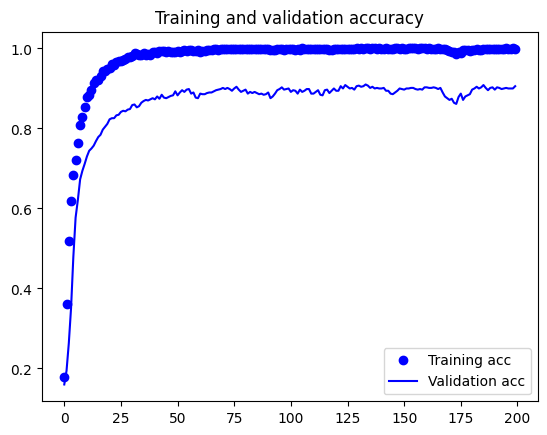

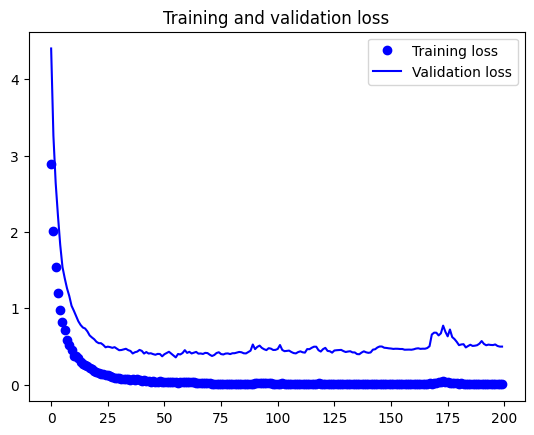

In [11]:
import matplotlib.pyplot as plt

acc = history.history['sparse_categorical_accuracy']
val_acc = history.history['val_sparse_categorical_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()